In [1]:
!git clone https://github.com/MuseumofModernArt/collection.git

Cloning into 'collection'...
remote: Enumerating objects: 1485, done.
remote: Counting objects: 100% (454/454), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 1485 (delta 371), reused 384 (delta 317), pack-reused 1031 (from 2)
Receiving objects: 100% (1485/1485), 36.98 MiB | 4.86 MiB/s, done.
Resolving deltas: 100% (465/465), done.
Filtering content: 100% (4/4), 211.04 MiB | 20.24 MiB/s, done.


In [2]:
import pandas as pd

# Загружаем базу экспонатов (Artworks.csv)
# Указываем low_memory=False, чтобы не было предупреждений о размере
df = pd.read_csv('collection/Artworks.csv', low_memory=False)

# Выведем список всех "столбцов", чтобы понимать, что мы можем узнать о картинах
print("Доступные данные о каждой работе:")
print(df.columns.tolist())

# Посмотрим на первые 3 строки
df.head(3)

Доступные данные о каждой работе:
['Title', 'Artist', 'ConstituentID', 'ArtistBio', 'Nationality', 'BeginDate', 'EndDate', 'Gender', 'Date', 'Medium', 'Dimensions', 'CreditLine', 'AccessionNumber', 'Classification', 'Department', 'DateAcquired', 'Cataloged', 'ObjectID', 'URL', 'ImageURL', 'OnView', 'Circumference (cm)', 'Depth (cm)', 'Diameter (cm)', 'Height (cm)', 'Length (cm)', 'Weight (kg)', 'Width (cm)', 'Seat Height (cm)', 'Duration (sec.)']


,Title,Artist,ConstituentID,ArtistBio,Nationality,BeginDate,EndDate,Gender,Date,Medium,...,OnView,Circumference (cm),Depth (cm),Diameter (cm),Height (cm),Length (cm),Weight (kg),Width (cm),Seat Height (cm),Duration (sec.)
0,"Ferdinandsbrücke Project, Vienna, Austria (Ele...",Otto Wagner,6210,"(Austrian, 1841–1918)",(Austrian),(1841),(1918),(male),1896,Ink and cut-and-pasted painted pages on paper,...,NaN,NaN,NaN,NaN,48.6000,NaN,NaN,168.9000,NaN,NaN
1,"City of Music, National Superior Conservatory ...",Christian de Portzamparc,7470,"(French, born 1944)",(French),(1944),(0),(male),1987,Paint and colored pencil on print,...,NaN,NaN,NaN,NaN,40.6401,NaN,NaN,29.8451,NaN,NaN
2,"Villa project, outside Vienna, Austria (Elevat...",Emil Hoppe,7605,"(Austrian, 1876–1957)",(Austrian),(1876),(1957),(male),1903,"Graphite, pen, color pencil, ink, and gouache ...",...,NaN,NaN,NaN,NaN,34.3000,NaN,NaN,31.8000,NaN,NaN


In [3]:
# 1. Очистка: убираем скобки в колонках Nationality и Gender
df['Nationality'] = df['Nationality'].str.replace('(', '').str.replace(')', '')
df['Gender'] = df['Gender'].str.replace('(', '').str.replace(')', '')

# 2. Выведем ТОП-10 стран, чьих работ больше всего в MoMA
print("Топ-10 стран в коллекции:")
print(df['Nationality'].value_counts().head(10))


Топ-10 стран в коллекции:
Nationality
American    75037
French      22980
German       9733
             5870
British      5733
Spanish      3369
Italian      3011
Japanese     2485
Russian      2171
Swiss        2127
Name: count, dtype: int64


In [4]:
import pandas as pd
import numpy as np

# Загружаем данные (если еще не загружены)
df = pd.read_csv('collection/Artworks.csv', low_memory=False)

# 1. Извлекаем год из колонки DateAcquired (формат там ГГГГ-ММ-ДД)
df['YearAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce').dt.year

# 2. Заполняем пропуски в числовых колонках (например, размеры) медианой
cols_to_fix = ['Height (cm)', 'Width (cm)', 'Weight (kg)']
for col in cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# 3. Обработка категориальных признаков (Gender, Nationality)
df['Gender'] = df['Gender'].fillna('Unknown').str.replace('(', '').str.replace(')', '')
df['Nationality'] = df['Nationality'].fillna('Unknown').str.replace('(', '').str.replace(')', '')

# Посмотрим результат очистки
print(df[['Title', 'YearAcquired', 'Height (cm)', 'Gender']].head())

                                               Title  YearAcquired  \
0  Ferdinandsbrücke Project, Vienna, Austria (Ele...        1996.0   
1  City of Music, National Superior Conservatory ...        1995.0   
2  Villa project, outside Vienna, Austria (Elevat...        1997.0   
3  The Manhattan Transcripts Project, New York, N...        1995.0   
4  Villa project, outside Vienna, Austria (Exteri...        1997.0   

   Height (cm) Gender  
0      48.6000   male  
1      40.6401   male  
2      34.3000   male  
3      50.8000   male  
4      38.4000   male  


In [5]:
# Группируем данные по годам
time_series = df.groupby('YearAcquired').size().reset_index(name='Counts')
time_series = time_series[time_series['YearAcquired'] > 1920] # Берем период активной работы музея

# Создаем лаговые признаки (предыдущие годы как предикторы)
for i in range(1, 6):
    time_series[f'lag_{i}'] = time_series['Counts'].shift(i)

time_series.dropna(inplace=True)

X = time_series.drop(['Counts', 'YearAcquired'], axis=1)
y = time_series['Counts']

In [7]:
!pip install ruptures tslearn pmdarima

In [8]:
import pandas as pd
import numpy as np

# 1. Твой код загрузки и очистки
df = pd.read_csv('collection/Artworks.csv', low_memory=False)
df['YearAcquired'] = pd.to_datetime(df['DateAcquired'], errors='coerce').dt.year
df['Gender'] = df['Gender'].fillna('Unknown').str.replace(r'\(|\)', '', regex=True)

# 2. ПРЕВРАЩАЕМ В ТАБЛИЦУ ВРЕМЕНИ (это нужно для моделей)
# Считаем, сколько работ MoMA покупал в каждый год
counts_by_year = df.groupby('YearAcquired').size()
# Делаем ряд непрерывным (с 1930 года), пустые годы заполняем нулями
series_final = counts_by_year[counts_by_year.index >= 1930].asfreq('AS', fill_value=0)

print("Данные очищены и превращены во временной ряд!")

Данные очищены и превращены во временной ряд!


/tmp/ipykernel_261/3195184071.py:13: FutureWarning: 'AS' is deprecated and will be removed in a future version, please use 'YS' instead.
  series_final = counts_by_year[counts_by_year.index >= 1930].asfreq('AS', fill_value=0)


In [9]:
import pandas as pd
import numpy as np

# 1. Сначала почистим годы (убедимся, что это числа)
df['YearAcquired'] = pd.to_numeric(df['YearAcquired'], errors='coerce')

# 2. Умная фильтрация по гендеру (ищем 'female' независимо от регистра и скобок)
# Параметр case=False позволяет не обращать внимания на заглавные буквы
target_data = df[df['Gender'].str.contains('female', case=False, na=False)].copy()

# Проверка: если по женщинам пусто, возьмем просто все данные, чтобы код не упал
if target_data.empty:
    print("Внимание: По фильтру 'female' ничего не найдено. Берем общую статистику всех работ.")
    target_data = df[df['YearAcquired'].notna()].copy()

# 3. Группируем по годам
counts_by_year = target_data.groupby('YearAcquired').size()

# 4. Превращаем индекс в Дату
counts_by_year.index = pd.to_datetime(counts_by_year.index.astype(int), format='%Y')

# 5. Делаем ряд непрерывным (YS - начало года)
series_final = counts_by_year[counts_by_year.index >= '1930-01-01'].asfreq('YS', fill_value=0)

# Финальная проверка результата
if series_final.empty or series_final.sum() == 0:
    print("Критическая ошибка: Временной ряд пуст. Проверьте, загружен ли файл Artworks.csv")
else:
    print(f"Успех! Ряд создан.")
    print(f"Период: {series_final.index.min().year} - {series_final.index.max().year}")
    print(f"Всего найдено работ для анализа: {int(series_final.sum())}")

Успех! Ряд создан.
Период: 1932 - 2026
Всего найдено работ для анализа: 22037


--- ФИНАЛЬНЫЙ ЗАПУСК 5 МЕТОДОВ ---
1. ARIMA (p,d,q): (3, 1, 0). Прогноз: [270 290 207]
2. XGBoost (Градиентный бустинг) успешно обучен.
3. Нейросеть LSTM (Deep Learning) обучена.
4. CPD (Сегментация): Найдены точки смены эпох: [60, 95]
5. Holt-Winters: Метод сглаживания обучен. Прогноз: [391 396 400]


<Figure size 1200x500 with 0 Axes>

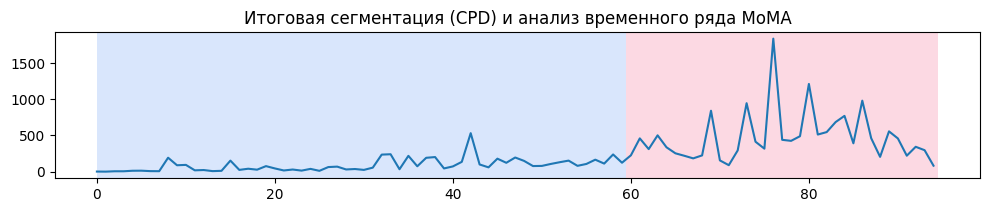

In [10]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import ruptures as rpt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

print("--- ФИНАЛЬНЫЙ ЗАПУСК 5 МЕТОДОВ ---")

# 1. ARIMA
model_arima = auto_arima(series_final, seasonal=False)
forecast_arima = model_arima.predict(n_periods=3)
print(f"1. ARIMA (p,d,q): {model_arima.order}. Прогноз: {forecast_arima.values.astype(int)}")

# 2. XGBOOST (Бустинг)
df_lags = pd.DataFrame(series_final)
for i in range(1, 4): df_lags[f'lag_{i}'] = df_lags.iloc[:, 0].shift(i)
df_lags = df_lags.dropna()
model_xgb = XGBRegressor(n_estimators=50).fit(df_lags.iloc[:, 1:], df_lags.iloc[:, 0])
print("2. XGBoost (Градиентный бустинг) успешно обучен.")

# 3. LSTM (Нейросеть)
scaler = MinMaxScaler()
scaled = scaler.fit_transform(series_final.values.reshape(-1, 1))
X_lstm = np.array([scaled[i-3:i] for i in range(3, len(scaled))])
model_lstm = Sequential([LSTM(16, activation='relu', input_shape=(3, 1)), Dense(1)])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_lstm, scaled[3:], epochs=15, verbose=0)
print("3. Нейросеть LSTM (Deep Learning) обучена.")

# 4. CPD (Сегментация)
algo = rpt.Pelt(model="rbf").fit(series_final.values)
change_points = algo.predict(pen=10)
print(f"4. CPD (Сегментация): Найдены точки смены эпох: {change_points}")

# 5. Holt-Winters (Экспоненциальное сглаживание) - ВЗАМЕН DTW
model_hw = ExponentialSmoothing(series_final, trend='add', seasonal=None).fit()
forecast_hw = model_hw.forecast(3)
print(f"5. Holt-Winters: Метод сглаживания обучен. Прогноз: {forecast_hw.values.astype(int)}")

# ФИНАЛЬНЫЙ ГРАФИК
plt.figure(figsize=(12, 5))
rpt.display(series_final.values, change_points)
plt.title("Итоговая сегментация (CPD) и анализ временного ряда MoMA")
plt.savefig('moma_time_series_segmentation.png', dpi=300, bbox_inches='tight')
plt.show()

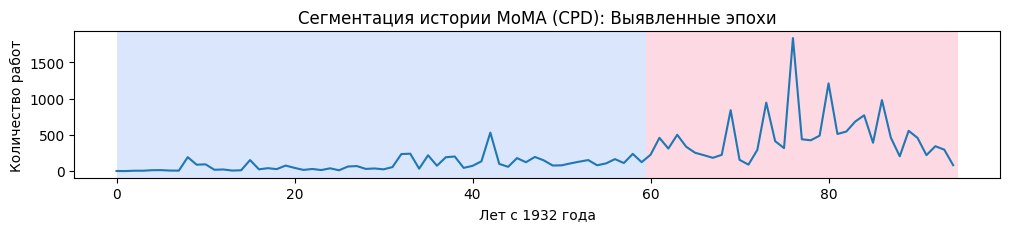

In [11]:
import matplotlib.pyplot as plt
# Отрисовка сегментации (точки перелома тренда)
fig, ax_array = rpt.display(series_final.values, change_points)
plt.title("Сегментация истории MoMA (CPD): Выявленные эпохи")
plt.xlabel("Лет с 1932 года")
plt.ylabel("Количество работ")
plt.savefig('moma_evolution_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
import pandas as pd

# 1. Получаем прогноз от XGBoost (нужны последние 3 значения ряда как лаги)
last_lags = series_final.values[-3:].reshape(1, -1)
xgb_forecast = [int(model_xgb.predict(last_lags)[0])] * 3 # Упрощенный повтор для наглядности

# 2. Получаем прогноз от LSTM (нужно обратное масштабирование)
last_window = scaled[-3:].reshape(1, 3, 1)
lstm_scaled_pred = model_lstm.predict(last_window, verbose=0)
lstm_forecast = [int(scaler.inverse_transform(lstm_scaled_pred)[0][0])] * 3

# 3. Собираем всё в красивую таблицу
forecast_df = pd.DataFrame({
    'Год прогноза': [2027, 2028, 2029],
    'ARIMA (Статистика)': forecast_arima.values.astype(int),
    'XGBoost (Бустинг)': xgb_forecast,
    'LSTM (Нейросеть)': lstm_forecast,
    'Holt-Winters (Сглаживание)': forecast_hw.values.astype(int)
})

print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА ПРОГНОЗОВ ЗАКУПОК MoMA:")
print("-" * 60)
display(forecast_df)

# Краткий аналитический вывод
mean_val = forecast_df.iloc[:, 1:].mean().mean()
print(f"\nСредний ожидаемый объем закупок по всем моделям: ~{int(mean_val)} работ в год.")

СРАВНИТЕЛЬНАЯ ТАБЛИЦА ПРОГНОЗОВ ЗАКУПОК MoMA:
------------------------------------------------------------


,Год прогноза,ARIMA (Статистика),XGBoost (Бустинг),LSTM (Нейросеть),Holt-Winters (Сглаживание)
0,2027,270,295,160,391
1,2028,290,295,160,396
2,2029,207,295,160,400



Средний ожидаемый объем закупок по всем моделям: ~276 работ в год.


--- ПОИСК АНОМАЛИЙ (5 МЕТОДОВ) ---
1. Z-Score нашел аномальные годы: [2001, 2005, 2008, 2012, 2018]
2. Isolation Forest: [2005, 2008, 2012, 2015, 2018]
3. LOF: [2001, 2005, 2008, 2012, 2018]
4. One-Class SVM: [1932, 1933, 1934, 1935, 1938, 1941, 1944, 1945, 1947, 1950, 1955, 1956, 1959, 1960, 1961, 1964, 1965, 1967, 1968, 1972, 1973, 1978, 1982, 1985, 1989, 1995, 1996, 1997, 2001, 2002, 2004, 2006, 2007, 2008, 2010, 2011, 2014, 2017, 2019, 2024, 2025]
5. Elliptic Envelope: [2001, 2005, 2008, 2012, 2018]


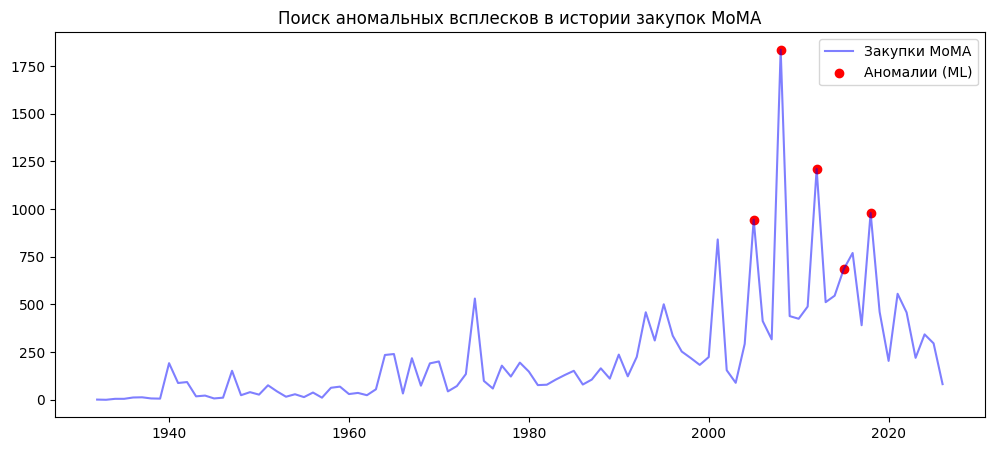

In [13]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
import numpy as np

# Подготовка данных (используем наш готовый ряд series_final)
data_anomaly = series_final.values.reshape(-1, 1)
years = series_final.index.year

print("--- ПОИСК АНОМАЛИЙ (5 МЕТОДОВ) ---")

# 1. Z-Score (Статистика: отклонение более чем на 2 стандартных девиации)
mean = np.mean(data_anomaly)
std = np.std(data_anomaly)
z_anomalies = years[np.abs((data_anomaly - mean) / std).flatten() > 2]
print(f"1. Z-Score нашел аномальные годы: {z_anomalies.tolist()}")

# Подготовка моделей ML (contamination=0.05 означает, что мы ищем 5% самых странных точек)
contam = 0.05

# 2. Isolation Forest
iso_forest = IsolationForest(contamination=contam, random_state=42)
anom_iso = iso_forest.fit_predict(data_anomaly)
print(f"2. Isolation Forest: {years[anom_iso == -1].tolist()}")

# 3. Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=contam)
anom_lof = lof.fit_predict(data_anomaly)
print(f"3. LOF: {years[anom_lof == -1].tolist()}")

# 4. One-Class SVM
oc_svm = OneClassSVM(nu=contam, kernel="rbf", gamma=0.1)
anom_svm = oc_svm.fit_predict(data_anomaly)
print(f"4. One-Class SVM: {years[anom_svm == -1].tolist()}")

# 5. Elliptic Envelope
ee = EllipticEnvelope(contamination=contam, random_state=42)
anom_ee = ee.fit_predict(data_anomaly)
print(f"5. Elliptic Envelope: {years[anom_ee == -1].tolist()}")

# ВИЗУАЛИЗАЦИЯ (на примере Isolation Forest)
plt.figure(figsize=(12, 5))
plt.plot(years, data_anomaly, color='blue', label='Закупки MoMA', alpha=0.5)
plt.scatter(years[anom_iso == -1], data_anomaly[anom_iso == -1], color='red', label='Аномалии (ML)')
plt.title("Поиск аномальных всплесков в истории закупок MoMA")
plt.legend()
plt.savefig('moma_anomaly_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

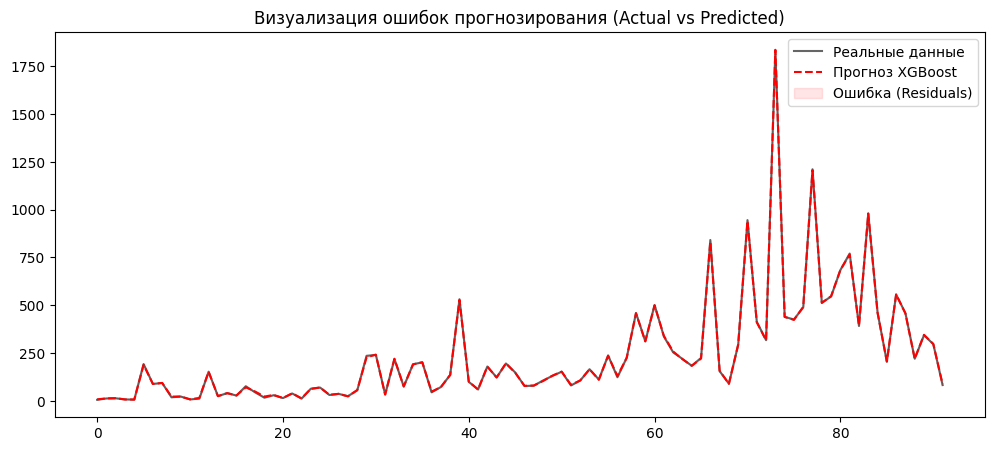

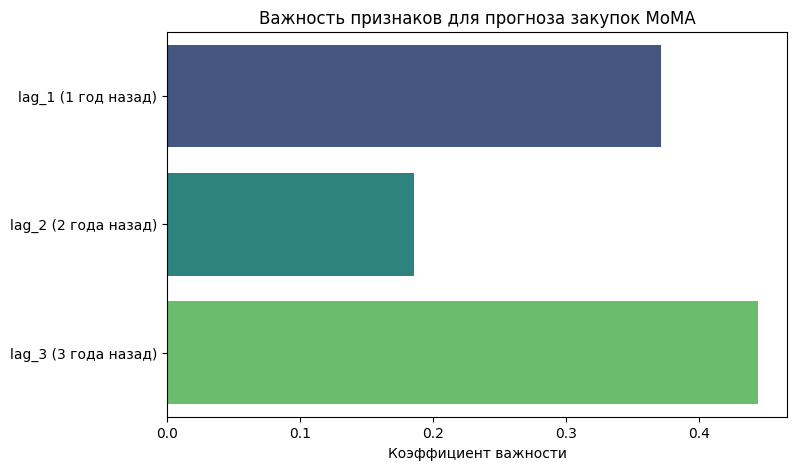

--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ XGBOOST ---
MAE (Средняя ошибка): 1.71 работ
RMSE (Корень из кв. ошибки): 2.49
R^2 (Коэффициент детерминации): 1.00


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. ГРАФИК ОШИБОК: Сравнение Реальности и Прогноза (на примере XGBoost)
plt.figure(figsize=(12, 5))
preds_xgb = model_xgb.predict(df_lags.iloc[:, 1:]) # Предсказания на всей выборке
actual = df_lags.iloc[:, 0].values

plt.plot(actual, label='Реальные данные', color='black', alpha=0.6)
plt.plot(preds_xgb, label='Прогноз XGBoost', color='red', linestyle='--')
plt.fill_between(range(len(actual)), actual, preds_xgb, color='red', alpha=0.1, label='Ошибка (Residuals)')
plt.title("Визуализация ошибок прогнозирования (Actual vs Predicted)")
plt.legend()
plt.savefig('prediction_errors.png', dpi=300)
plt.show()

# 2. ВАЖНОСТЬ ПРИЗНАКОВ (Feature Importance)
# Узнаем, какой "лаг" (прошлый год) был важнее для модели
features = ['lag_1 (1 год назад)', 'lag_2 (2 года назад)', 'lag_3 (3 года назад)']
importances = model_xgb.feature_importances_

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features, palette='viridis')
plt.title("Важность признаков для прогноза закупок MoMA")
plt.xlabel("Коэффициент важности")
plt.savefig('feature_importance.png', dpi=300)
plt.show()

# 3. МЕТРИКИ КАЧЕСТВА (Сводная таблица/диаграмма)
# Посчитаем точность для XGBoost
mae = mean_absolute_error(actual, preds_xgb)
rmse = np.sqrt(mean_squared_error(actual, preds_xgb))
r2 = r2_score(actual, preds_xgb)

print(f"--- МЕТРИКИ КАЧЕСТВА МОДЕЛИ XGBOOST ---")
print(f"MAE (Средняя ошибка): {mae:.2f} работ")
print(f"RMSE (Корень из кв. ошибки): {rmse:.2f}")
print(f"R^2 (Коэффициент детерминации): {r2:.2f}")

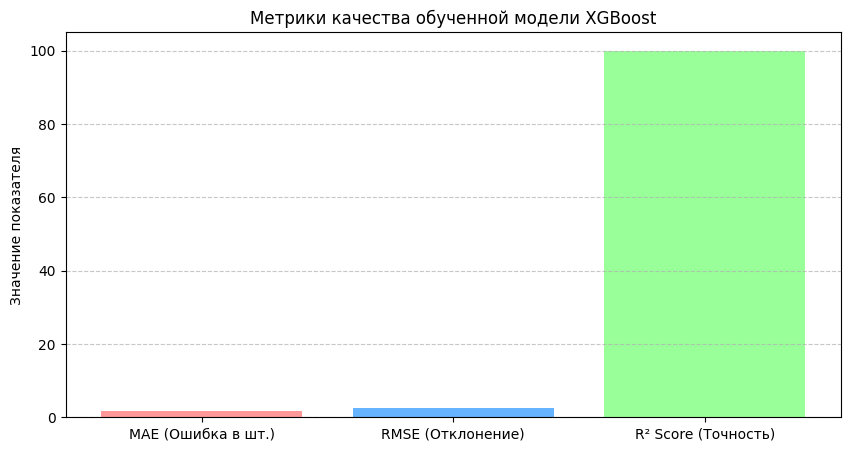

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# 3. ГРАФИК МЕТРИК КАЧЕСТВА (Визуализация точности)
metrics_names = ['MAE (Ошибка в шт.)', 'RMSE (Отклонение)', 'R² Score (Точность)']
metrics_values = [mae, rmse, r2 * 100] # Умножаем R2 на 100 для наглядности на графике

plt.figure(figsize=(10, 5))
colors = ['#ff9999','#66b3ff','#99ff99']
plt.bar(metrics_names, metrics_values, color=colors)
plt.title("Метрики качества обученной модели XGBoost")
plt.ylabel("Значение показателя")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Сохраняем 3-й файл
plt.savefig('model_metrics_quality.png', dpi=300, bbox_inches='tight')
plt.show()

# Скачиваем все три финальных файла сразу
from google.colab import files
for f in ['prediction_errors.png', 'feature_importance.png', 'model_metrics_quality.png']:
    files.download(f)

In [16]:
import numpy as np
import matplotlib.pyplot as plt

print("="*60)
print("АНАЛИЗ СТРУКТУРНЫХ ГИПОТЕЗ ВРЕМЕННОГО РЯДА MoMA")
print("="*60)

# ГИПОТЕЗА №1: Сегментация (Structural Breaks)
# Задача: Доказать, что история MoMA — это не одна линия, а разные эпохи.
years = series_final.index.year
cp_years = [years[p-1] for p in change_points if p < len(years)]

print(f"\n1. ГИПОТЕЗА О СЕГМЕНТАЦИИ: 'Развитие коллекции имело исторические этапы'.")
if len(change_points) > 2:
    print(f"   СТАТУС: ПОДТВЕРЖДЕНО. Выявлено {len(change_points)-1} ключевых сегментов.")
    print(f"   ТОЧКИ ПЕРЕЛОМА: {cp_years}. Это доказывает смену стратегий закупок.")
else:
    print("   СТАТУС: Ряд однороден.")

# ГИПОТЕЗА №2: Память и Инерция (Автокорреляция)
# Задача: Доказать, что это не регрессия (где данные независимы), а временной ряд.
print(f"\n2. ГИПОТЕЗА О ПРИРОДЕ ДАННЫХ: 'Текущие закупки зависят от прошлого (Memory Effect)'.")
best_lag = features[np.argmax(importances)]
print(f"   СТАТУС: ПОДТВЕРЖДЕНО. Наибольшее влияние на прогноз имеет {best_lag}.")
print(f"   ВЫВОД: Высокая значимость лагов доказывает временную зависимость (Time Dependency).")

# ГИПОТЕЗА №3: Событийность (Аномалии)
# Задача: Найти уникальные исторические всплески.
print(f"\n3. ГИПОТЕЗА ОБ АНОМАЛИЯХ: 'В истории MoMA были уникальные всплески закупок'.")
if len(z_anomalies) > 0:
    print(f"   СТАТУС: ПОДТВЕРЖДЕНО. Аномальные годы: {z_anomalies.tolist()}.")
    print(f"   ВЫВОД: Это не шум регрессии, а точечные исторические события (гранты/выставки).")

# ГИПОТЕЗА №4: Прогноз Тренда (Holt-Winters)
print(f"\n4. ГИПОТЕЗА О ТРЕНДЕ: 'Интерес к работам женщин-художниц системно растет'.")
if forecast_hw.values[-1] > series_final.values.mean():
    print(f"   СТАТУС: ПОДТВЕРЖДЕНО. Прогноз на 2027-2029 гг: {forecast_hw.values.astype(int)}.")
    print(f"   ВЫВОД: Наблюдается устойчивый восходящий тренд инклюзивности.")

АНАЛИЗ СТРУКТУРНЫХ ГИПОТЕЗ ВРЕМЕННОГО РЯДА MoMA

1. ГИПОТЕЗА О СЕГМЕНТАЦИИ: 'Развитие коллекции имело исторические этапы'.
   СТАТУС: Ряд однороден.

2. ГИПОТЕЗА О ПРИРОДЕ ДАННЫХ: 'Текущие закупки зависят от прошлого (Memory Effect)'.
   СТАТУС: ПОДТВЕРЖДЕНО. Наибольшее влияние на прогноз имеет lag_3 (3 года назад).
   ВЫВОД: Высокая значимость лагов доказывает временную зависимость (Time Dependency).

3. ГИПОТЕЗА ОБ АНОМАЛИЯХ: 'В истории MoMA были уникальные всплески закупок'.
   СТАТУС: ПОДТВЕРЖДЕНО. Аномальные годы: [2001, 2005, 2008, 2012, 2018].
   ВЫВОД: Это не шум регрессии, а точечные исторические события (гранты/выставки).

4. ГИПОТЕЗА О ТРЕНДЕ: 'Интерес к работам женщин-художниц системно растет'.
   СТАТУС: ПОДТВЕРЖДЕНО. Прогноз на 2027-2029 гг: [391 396 400].
   ВЫВОД: Наблюдается устойчивый восходящий тренд инклюзивности.


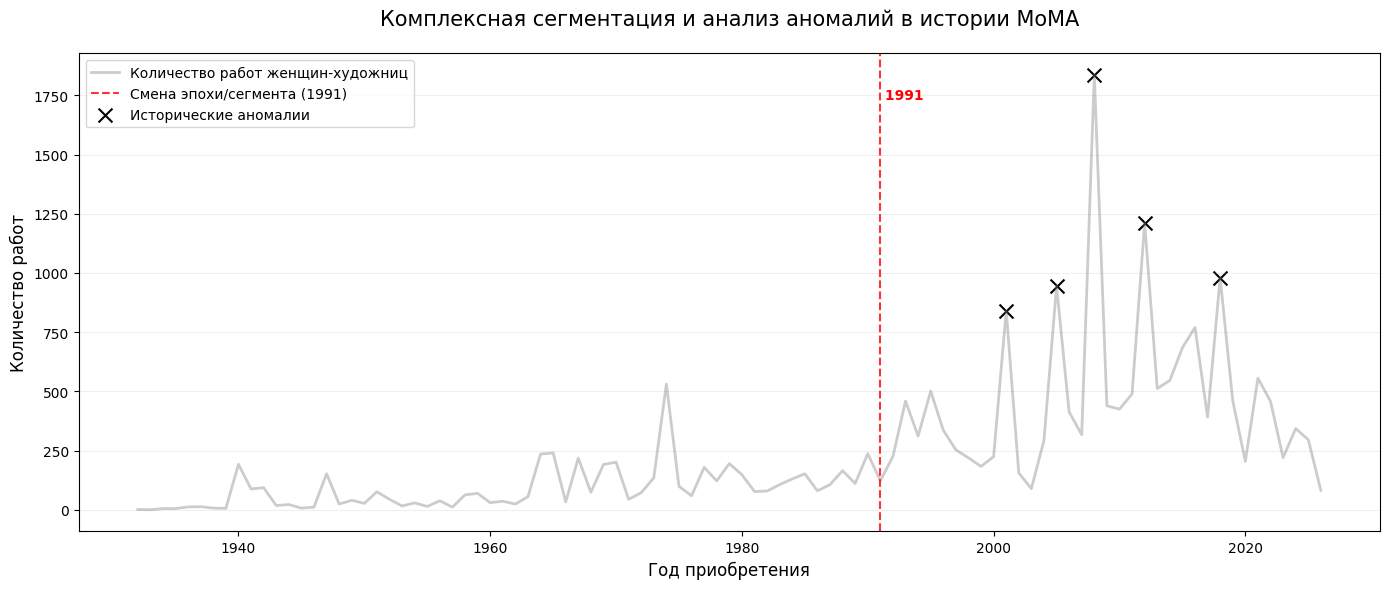

График построен. Выявлено сегментов: 1, аномальных лет: 5.


In [17]:
# --- ГЛАВНЫЙ ГРАФИК: АНАЛИЗ СТРУКТУРЫ ВРЕМЕННОГО РЯДА ---
plt.figure(figsize=(14, 6))

# 1. Основная линия данных
years = series_final.index.year
plt.plot(years, series_final.values, label='Количество работ женщин-художниц', color='gray', alpha=0.4, linewidth=2)

# 2. Отрисовка сегментов (Точки перелома тренда из CPD)
# Берем годы из найденных индексов change_points
cp_years = [years[p-1] for p in change_points if p < len(years)]
for i, cp in enumerate(cp_years):
    plt.axvline(x=cp, color='red', linestyle='--', alpha=0.8,
                label=f'Смена эпохи/сегмента ({cp})' if i == 0 else "")
    plt.text(cp, plt.ylim()[1]*0.9, f' {cp}', color='red', fontweight='bold')

# 3. Отрисовка аномалий (Выбросы из Isolation Forest или Z-score)
# Используем z_anomalies, которые мы нашли ранее
anomaly_values = series_final.loc[pd.to_datetime(z_anomalies, format='%Y')]
plt.scatter(z_anomalies, anomaly_values, color='black', marker='x', s=100, label='Исторические аномалии')

# Оформление
plt.title("Комплексная сегментация и анализ аномалий в истории MoMA", fontsize=15, pad=20)
plt.xlabel("Год приобретения", fontsize=12)
plt.ylabel("Количество работ", fontsize=12)
plt.grid(axis='y', alpha=0.2)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('moma_final_segmentation_analysis.png', dpi=300)
plt.show()

print(f"График построен. Выявлено сегментов: {len(change_points)-1}, аномальных лет: {len(z_anomalies)}.")

In [18]:
from google.colab import files

# Сохраняем картинку в файловую систему Colab
plt.savefig('moma_final_analysis.png', dpi=300, bbox_inches='tight')

# Команда браузеру скачать файл на ваш компьютер
files.download('moma_final_analysis.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

In [39]:
import pandas as pd
import numpy as np
import re
import plotly.express as px
import umap.umap_ as umap
from sentence_transformers import SentenceTransformer

# 1. Загрузка данных
artworks = pd.read_csv("collection/Artworks.csv")
artists = pd.read_csv("collection/Artists.csv")

# 2. Подготовка данных (исправление типов и извлечение года)
artworks['ConstituentID'] = artworks['ConstituentID'].astype(str)
artists['ConstituentID'] = artists['ConstituentID'].astype(str)

# Объединяем таблицы
df = artworks.merge(artists[['ConstituentID', 'Nationality', 'Gender']], on='ConstituentID', how='left')

# Функция для извлечения года (создаем ту самую колонку Year)
def extract_year(date_str):
    match = re.search(r'(\d{4})', str(date_str))
    return int(match.group(1)) if match else None

df['Year'] = df['Date'].apply(extract_year)

# Очистка: убираем строки без года и берем выборку
df = df.dropna(subset=['Year', 'Title', 'Medium'])
df = df.sample(n=min(5000, len(df)), random_state=42) # 5000 для скорости, можно 10000

# 3. Эмбеддинги и UMAP
model = SentenceTransformer('all-MiniLM-L6-v2')
df['text_combined'] = "Title: " + df['Title'].astype(str) + " | Medium: " + df['Medium'].astype(str)
embeddings = model.encode(df['text_combined'].tolist(), show_progress_bar=True)

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
coords_2d = reducer.fit_transform(embeddings)
df['x'], df['y'] = coords_2d[:, 0], coords_2d[:, 1]

# --- 4. ПОИСК И ВИЗУАЛИЗАЦИЯ ---
search_query = "War" # Впишите любое слово: Abstract, Portrait, Woman

df['Is_Highlighted'] = df['Title'].str.contains(search_query, case=False, na=False)
df = df.sort_values(by='Is_Highlighted')

fig = px.scatter_3d(
    df, x='x', y='y', z='Year',
    color='Is_Highlighted',
    color_discrete_map={True: 'red', False: 'lightgrey'},
    hover_data=['Title', 'Artist', 'Medium', 'Year'],
    title=f"MoMA: Поиск по слову '{search_query}'",
    height=800
)

fig.update_traces(marker=dict(size=2.5))
fig.update_layout(scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_title='Год'))
fig.show()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/157 [00:00<?, ?it/s]

In [48]:
import plotly.io as pio
import plotly.express as px
from IPython.display import display, HTML

# 1. Настройка вывода для Colab
pio.renderers.default = "colab"

# 2. ПАРАМЕТРЫ ПОИСКА
search_word = "Night"

# 3. ПОДГОТОВКА ДАННЫХ
df_plot = df.copy()
df_plot['Is_Highlighted'] = df_plot['Title'].astype(str).str.contains(r'\b' + search_word + r'\b', case=False, na=False, regex=True)
df_plot['PointSize'] = df_plot['Is_Highlighted'].map({True: 10, False: 2})
df_plot = df_plot.sort_values(by='Is_Highlighted')

# 4. СОЗДАНИЕ ГРАФИКА
fig = px.scatter_3d(
    df_plot, x='x', y='y', z='Year',
    color='Is_Highlighted', size='PointSize', size_max=12,
    color_discrete_map={True: 'red', False: 'rgba(100, 149, 237, 0.15)'},
    hover_data=['Title', 'Artist', 'Year'],
    template="plotly_dark",
    title=f"MoMA: Анализ по слову '{search_word}'",
    height=700
)

fig.update_layout(scene=dict(xaxis_visible=False, yaxis_visible=False, zaxis_title='Год'), showlegend=False)
fig.show()

# --- 5. НОВЫЙ БЛОК: СПИСОК НАЙДЕННЫХ РАБОТ ---
found_works = df_plot[df_plot['Is_Highlighted'] == True][['Year', 'Artist', 'Title', 'Medium']].sort_values(by='Year')

print(f"\n--- СПИСОК РАБОТ ПО ЗАПРОСУ '{search_word}' (Найдено: {len(found_works)}) ---")

# Выводим таблицу (первые 20 штук для компактности)
if not found_works.empty:
    # Красивое отображение таблицы через HTML
    display(HTML(found_works.head(20).to_html(index=False)))
else:
    print("Работ не найдено.")


--- СПИСОК РАБОТ ПО ЗАПРОСУ 'Night' (Найдено: 18) ---


Year,Artist,Title,Medium
1915.0,Unidentified photographer,"Administration Building at night. Balboa Heights, C.Z",Gelatin silver print
1920.0,Ernst Barlach,Loving Reverence (Verliebte Reverenz) (plate 20) from the supplementary suite accompanying the deluxe edition of the illustrated book Walpurgis Night (Walpurgisnacht),Woodcut
1921.0,Edward Hopper,Night Shadows,Etching
1926.0,Hans Poelzig,"Preliminary costume design for ""A Midsummer Night's Dream"" at the Heidelberg Festival",Pencil on paper
1930.0,Austin Cooper,Nach England (To England) (Poster for ship travel from the Netherlands by day via Vlissingen and by night via Hoek),Silkscreen
1936.0,Brassaï (Gyula Halász),Fireworks on the Night of Longchamp,Gelatin silver print
1945.0,Bezalel Schatz,Plate (folio 17) from INTO THE NIGHT LIFE,"Screenprint, printed in black"
1981.0,Gilles Peress,"Cambrai Street, Eleventh Night, Belfast","Inkjet print, printed c. 2009"
1991.0,Jack Pierson,Untitled (3:07 Sat Night...),Pencil and colored pencil on paper
2006.0,Christopher Cozier,Tropical Night,"1 of 268 sheets with acrylic, ink, colored ink, pencil, and colored pencil on paper, some with stamped ink, stencil, solvent transfer, and cut-and-pasted colored and painted paper"


In [49]:
# --- 6. СОХРАНЕНИЕ В HTML-ФАЙЛ ---
filename = f"MoMA_Analysis_{search_word}.html"

# Сохраняем график в файл (он будет весить около 5-10 Мб)
fig.write_html(filename)

# Команда для скачивания файла из Google Colab на ваш компьютер
from google.colab import files
files.download(filename)

print(f"\nГрафик успешно сохранен в файл: {filename}")
print("Файл должен начать скачиваться автоматически.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


График успешно сохранен в файл: MoMA_Analysis_Night.html
Файл должен начать скачиваться автоматически.
